<a href="https://colab.research.google.com/github/Luisgz1010/Inteligencia_Artificial_2/blob/main/IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importamos pandas para organizar y mostrar los datos en tablas.
import pandas as pd

# Importamos matplotlib para crear gráficos.
import matplotlib.pyplot as plt

# Importamos el Dataset Iris que viene incluido en Scikit-learn.
from sklearn.datasets import load_iris

# Importamos la función para dividir los datos en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# Importamos el árbol de decisión para realizar la clasificación.
from sklearn.tree import DecisionTreeClassifier

# Importamos las funciones necesarias para evaluar el modelo.
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Importamos una función para visualizar el árbol de decisión.
from sklearn.tree import plot_tree

In [3]:
# Cargamos el Dataset Iris.
iris = load_iris()

# Guardamos las características de las flores.
X = iris.data

# Guardamos las categorías o especies de las flores.
y = iris.target

# Obtenemos los nombres de las especies.
nombres_especies = iris.target_names

# Mostramos las especies disponibles.
print("Especies:", nombres_especies)

# Mostramos la cantidad total de flores.
print("Cantidad de flores:", len(X))

Especies: ['setosa' 'versicolor' 'virginica']
Cantidad de flores: 150


In [4]:
# Mostramos los nombres de las cuatro características.
print("Características:")

# Recorremos las características del Dataset Iris.
for caracteristica in iris.feature_names:

    # Mostramos cada característica.
    print("-", caracteristica)

Características:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [5]:
# Creamos una tabla utilizando las características del Dataset Iris.
df = pd.DataFrame(X, columns=iris.feature_names)

# Agregamos una columna con el número de la especie.
df["especie"] = y

# Agregamos otra columna con el nombre de la especie.
df["nombre_especie"] = df["especie"].map(
    {0: "Setosa", 1: "Versicolor", 2: "Virginica"}
)

# Mostramos las primeras 10 flores de la tabla.
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie,nombre_especie
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


In [6]:
# Contamos cuántas flores pertenecen a cada especie.
cantidad_especies = df["nombre_especie"].value_counts()

# Mostramos la cantidad de flores de cada especie.
print(cantidad_especies)

nombre_especie
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


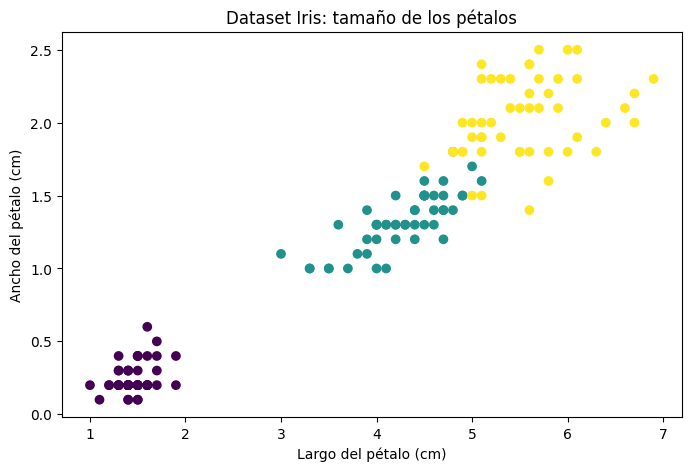

In [7]:
# Creamos un gráfico con el tamaño de los pétalos.
plt.figure(figsize=(8, 5))

# Dibujamos los datos de las flores.
plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=y
)

# Colocamos el nombre del eje horizontal.
plt.xlabel("Largo del pétalo (cm)")

# Colocamos el nombre del eje vertical.
plt.ylabel("Ancho del pétalo (cm)")

# Colocamos un título al gráfico.
plt.title("Dataset Iris: tamaño de los pétalos")

# Mostramos el gráfico.
plt.show()

In [8]:
# Dividimos los datos en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Mostramos cuántos datos utilizaremos para entrenar.
print("Datos de entrenamiento:", len(X_train))

# Mostramos cuántos datos utilizaremos para probar.
print("Datos de prueba:", len(X_test))

Datos de entrenamiento: 120
Datos de prueba: 30


In [9]:
# Creamos nuestro árbol de decisión.
modelo_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

# Entrenamos el árbol utilizando los datos de entrenamiento.
modelo_gini.fit(X_train, y_train)

# Mostramos un mensaje indicando que el entrenamiento terminó.
print("El árbol de decisión fue entrenado correctamente.")

El árbol de decisión fue entrenado correctamente.


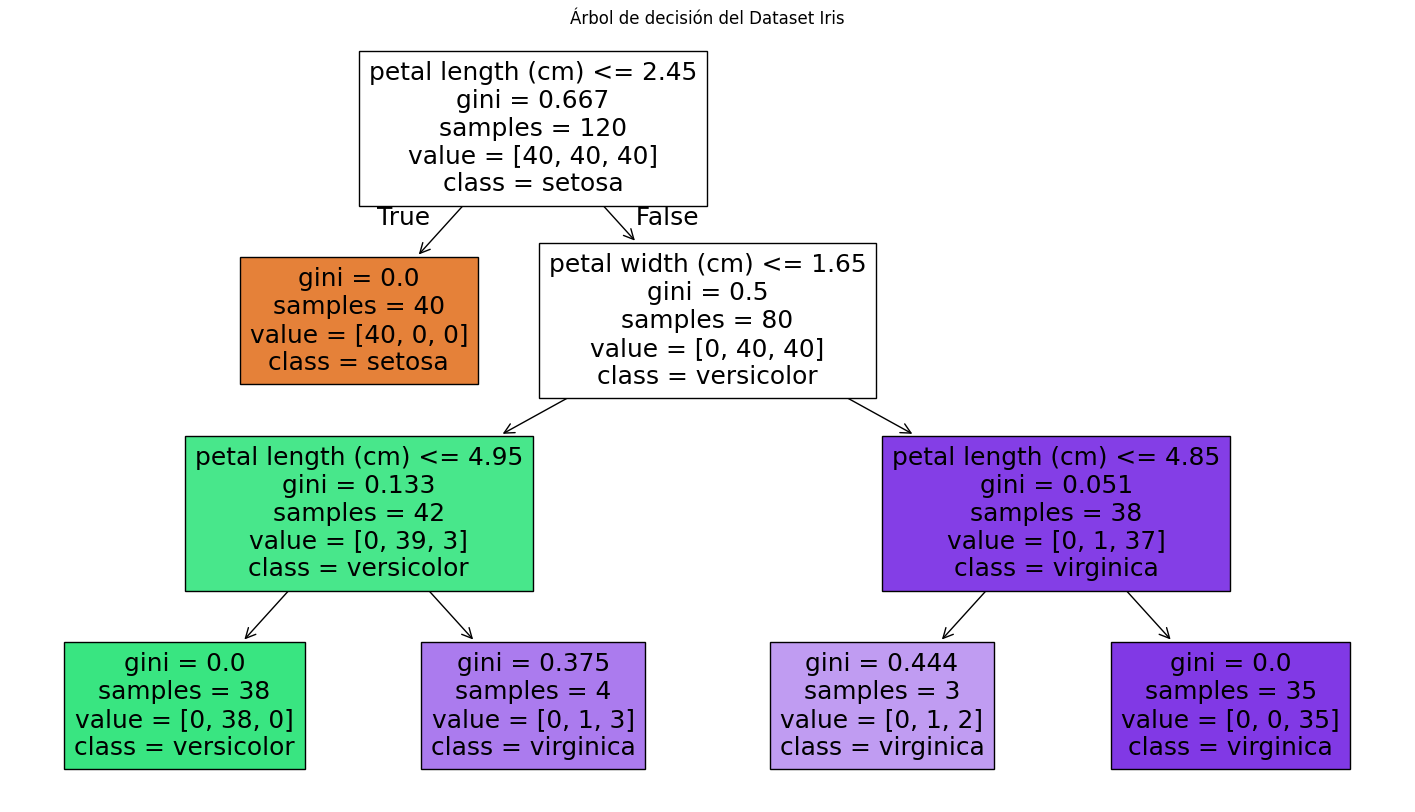

In [10]:
# Creamos un espacio para visualizar el árbol.
plt.figure(figsize=(18, 10))

# Dibujamos el árbol de decisión.
plot_tree(
    modelo_gini,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

# Colocamos un título.
plt.title("Árbol de decisión del Dataset Iris")

# Mostramos el árbol.
plt.show()

In [11]:
# Utilizamos el árbol para realizar predicciones.
predicciones = modelo_gini.predict(X_test)

# Mostramos las predicciones realizadas.
print("Predicciones del modelo:")

# Mostramos las primeras 10 predicciones.
print(predicciones[:10])

Predicciones del modelo:
[0 2 1 1 0 1 0 0 2 1]


In [12]:
# Comparamos las respuestas reales con las predicciones.
precision = accuracy_score(y_test, predicciones)

# Convertimos la precisión a porcentaje.
precision_porcentaje = precision * 100

# Mostramos el resultado.
print("Precisión del modelo:", precision_porcentaje, "%")

Precisión del modelo: 96.66666666666667 %


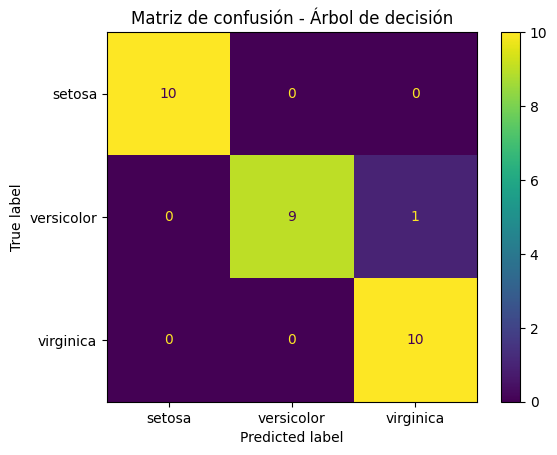

In [13]:
# Creamos la matriz de confusión.
matriz = confusion_matrix(y_test, predicciones)

# Creamos una representación visual de la matriz.
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=iris.target_names
)

# Mostramos la matriz.
disp.plot()

# Colocamos un título.
plt.title("Matriz de confusión - Árbol de decisión")

# Mostramos el gráfico.
plt.show()

In [14]:
# Creamos un árbol utilizando Gini.
modelo_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

# Entrenamos el modelo Gini.
modelo_gini.fit(X_train, y_train)

# Realizamos las predicciones con Gini.
pred_gini = modelo_gini.predict(X_test)

# Calculamos la precisión de Gini.
precision_gini = accuracy_score(y_test, pred_gini)

# Mostramos la precisión.
print("Precisión utilizando Gini:", precision_gini * 100, "%")

Precisión utilizando Gini: 96.66666666666667 %


In [15]:
# Creamos un árbol utilizando Entropía.
modelo_entropia = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

# Entrenamos el modelo utilizando Entropía.
modelo_entropia.fit(X_train, y_train)

# Realizamos las predicciones con Entropía.
pred_entropia = modelo_entropia.predict(X_test)

# Calculamos la precisión de Entropía.
precision_entropia = accuracy_score(y_test, pred_entropia)

# Mostramos la precisión.
print("Precisión utilizando Entropía:", precision_entropia * 100, "%")

Precisión utilizando Entropía: 96.66666666666667 %


In [16]:
# Creamos una nueva flor.
nueva_flor = [[5.1, 3.5, 1.4, 0.2]]

# Utilizamos el modelo para clasificar la nueva flor.
resultado = modelo_gini.predict(nueva_flor)

# Convertimos el número obtenido en el nombre de la especie.
especie_predicha = iris.target_names[resultado[0]]

# Mostramos la especie predicha.
print("La nueva flor pertenece a:", especie_predicha)

La nueva flor pertenece a: setosa
